In [1]:
# /kaggle/input/clc-xray/test/_annotations.coco.json

In [1]:
import os
import json
import glob

dataset_path = "/kaggle/input/clc-xray"

json_files = glob.glob(os.path.join(dataset_path, "*", "_annotations.coco.json"))
print("Annotation Files Found:", json_files)

annotation_path = os.path.join(dataset_path, "train", "_annotations.coco.json")

with open(annotation_path, "r") as f:
    json_data = json.load(f)

print("Keys in JSON:", json_data.keys())


Annotation Files Found: ['/kaggle/input/clc-xray/valid/_annotations.coco.json', '/kaggle/input/clc-xray/test/_annotations.coco.json', '/kaggle/input/clc-xray/train/_annotations.coco.json']
Keys in JSON: dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])


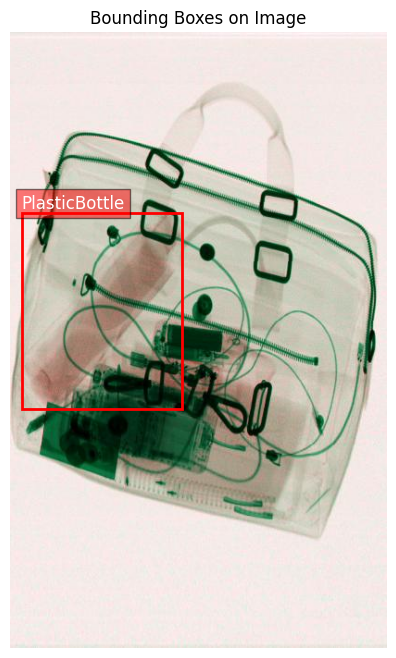

In [2]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

category_map = {cat["id"]: cat["name"] for cat in json_data["categories"]}

def plot_bboxes(image_dir, image_info, annotations):
    """Plots bounding boxes on an image using COCO annotations."""
    image_path = os.path.join(image_dir, image_info["file_name"])

    if not os.path.exists(image_path):
        print(f"Error: Image not found at {image_path}")
        return

    image = cv2.imread(image_path)
    if image is None:
        print("Error: Unable to read image. Check file format.")
        return

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(image)

    for ann in annotations:
        x, y, w, h = ann["bbox"]
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y - 5, category_map.get(ann["category_id"], "Unknown"), 
                color="white", fontsize=12, bbox=dict(facecolor='red', alpha=0.5))

    plt.axis("off")
    plt.title("Bounding Boxes on Image")
    plt.show()

image_sample = json_data["images"][0]
image_dir = os.path.join(dataset_path, "train")  # Adjust for test/valid if needed
image_annotations = [ann for ann in json_data["annotations"] if ann["image_id"] == image_sample["id"]]

plot_bboxes(image_dir, image_sample, image_annotations)


In [3]:
import glob

train_images = glob.glob(os.path.join(dataset_path, "train", "*.*"))
test_images = glob.glob(os.path.join(dataset_path, "test", "*.*"))
valid_images = glob.glob(os.path.join(dataset_path, "valid", "*.*"))

print(f"Train Images: {len(train_images)} | Sample: {train_images[:5]}")
print(f"Test Images: {len(test_images)} | Sample: {test_images[:5]}")
print(f"Valid Images: {len(valid_images)} | Sample: {valid_images[:5]}")


Train Images: 3187 | Sample: ['/kaggle/input/clc-xray/train/14_40_57_902_png.rf.b22655f7f996cb15ebe22352da3ca316.jpg', '/kaggle/input/clc-xray/train/20_23_15_859_png.rf.fff05ae10df04be916c8686da7d07500.jpg', '/kaggle/input/clc-xray/train/14_41_06_754_png.rf.02656f934727d060b3c365360989d998.jpg', '/kaggle/input/clc-xray/train/15_27_02_225_png.rf.1d83d3ab8d6781927e65fd3813e36376.jpg', '/kaggle/input/clc-xray/train/11_26_16_589_png.rf.cbe70bafa3cfb2d566e63ff52a55b520.jpg']
Test Images: 957 | Sample: ['/kaggle/input/clc-xray/test/20_37_29_671_png.rf.1286d40d36684ffc548c8ec1040d32cb.jpg', '/kaggle/input/clc-xray/test/13_38_09_250_png.rf.b25716a99761f06fd425c06a18b0c6be.jpg', '/kaggle/input/clc-xray/test/06_52_33_484_png.rf.422794b05ac18ede6344152fd169ce51.jpg', '/kaggle/input/clc-xray/test/06_30_14_000_png.rf.c2d8f6768498d027eb5ed391a84365e9.jpg', '/kaggle/input/clc-xray/test/09_58_01_779_png.rf.cfc77bccc128b790c004e3acfd28c179.jpg']
Valid Images: 957 | Sample: ['/kaggle/input/clc-xray/vali

In [4]:
output_path = "/kaggle/working/clc-xray-yolo"
os.makedirs(output_path, exist_ok=True)

json_files = glob.glob(os.path.join(dataset_path, "*", "_annotations.coco.json"))

def convert_coco_to_yolo(json_path, split):
    """Convert COCO JSON to YOLO format and save annotations."""
    with open(json_path, "r") as f:
        data = json.load(f)

    category_map = {cat["id"]: cat["name"] for cat in data["categories"]}
    
    # Make YOLO annotation folder
    label_dir = os.path.join(output_path, split, "labels")
    os.makedirs(label_dir, exist_ok=True)
    
    # Process each annotation
    for ann in data["annotations"]:
        image_info = next(img for img in data["images"] if img["id"] == ann["image_id"])
        img_w, img_h = image_info["width"], image_info["height"]
        
        # YOLO format: Normalize bbox values
        x, y, w, h = ann["bbox"]
        x_center, y_center = x + w / 2, y + h / 2
        x_center /= img_w
        y_center /= img_h
        w /= img_w
        h /= img_h
        
        # Save annotation
        label_path = os.path.join(label_dir, os.path.splitext(image_info["file_name"])[0] + ".txt")
        with open(label_path, "a") as f:
            f.write(f"{ann['category_id']} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")

    print(f"✅ YOLO annotations saved for {split} in {label_dir}")

# Convert all dataset splits
for json_file in json_files:
    split = os.path.basename(os.path.dirname(json_file))  # Extract train/test/valid
    convert_coco_to_yolo(json_file, split)


✅ YOLO annotations saved for valid in /kaggle/working/clc-xray-yolo/valid/labels
✅ YOLO annotations saved for test in /kaggle/working/clc-xray-yolo/test/labels
✅ YOLO annotations saved for train in /kaggle/working/clc-xray-yolo/train/labels


📊 Class Distribution: {'blade': 1597, 'VacuumCup': 1213, 'GlassBottle': 351, 'Cans': 409, 'scissors': 1201, 'Tin': 466, 'PlasticBottle': 3196, 'SprayCans': 571, 'CartonDrinks': 954, 'SwissArmyKnife': 496, 'dagger': 494, 'knife': 347}


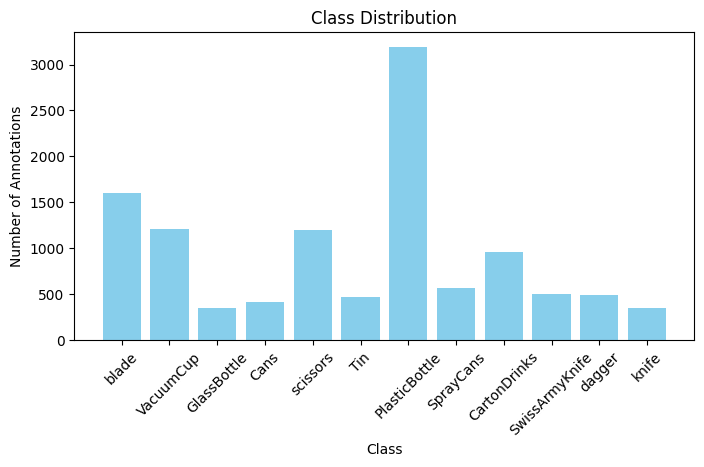

In [5]:
from collections import Counter

label_counts = Counter()

for json_file in json_files:
    with open(json_file, "r") as f:
        data = json.load(f)
    
    for ann in data["annotations"]:
        label_counts[ann["category_id"]] += 1

category_map = {cat["id"]: cat["name"] for cat in data["categories"]}
label_counts_named = {category_map[k]: v for k, v in label_counts.items()}

print("📊 Class Distribution:", label_counts_named)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.bar(label_counts_named.keys(), label_counts_named.values(), color="skyblue")
plt.xticks(rotation=45)
plt.xlabel("Class")
plt.ylabel("Number of Annotations")
plt.title("Class Distribution")
plt.show()


In [6]:
import shutil

for split in ["train", "valid", "test"]:
    src_img_dir = os.path.join(dataset_path, split)
    dest_img_dir = os.path.join(output_path, split, "images")
    os.makedirs(dest_img_dir, exist_ok=True)

    # Move images
    for img_file in glob.glob(os.path.join(src_img_dir, "*.*")):
        shutil.copy(img_file, dest_img_dir)

print("✅ Dataset Organized in YOLO format!")


✅ Dataset Organized in YOLO format!


In [7]:
data_yaml = """
train: /kaggle/working/clc-xray-yolo/train/images
val: /kaggle/working/clc-xray-yolo/valid/images
test: /kaggle/working/clc-xray-yolo/test/images

nc: 13
names: ['VacuumCup', 'PlasticBottle', 'Cans', 'blade', 'Tin', 'scissors', 'SwissArmyKnife', 'SprayCans', 'dagger', 'CartonDrinks', 'knife', 'GlassBottle', 'Other']
"""

with open("/kaggle/working/clc-xray-yolo/data.yaml", "w") as f:
    f.write(data_yaml)


In [8]:
!pip install ultralytics --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 976.9/976.9 kB 15.4 MB/s eta 0:00:00a 0:00:01


In [9]:
!pip install torch torchvision opencv-python numpy matplotlib pyyaml tqdm

In [10]:
import json
import glob

# Locate one annotation file (train set is usually the best choice)
annotation_file = glob.glob("/kaggle/input/clc-xray/train/_annotations.coco.json")[0]

# Load COCO JSON
with open(annotation_file, "r") as f:
    json_data = json.load(f)

# Extract category ID → Name mapping from the dataset
dataset_classes = {cat["id"]: cat["name"] for cat in json_data["categories"]}

# Print the actual class order from dataset
sorted_classes = [dataset_classes[i] for i in sorted(dataset_classes.keys())]
print("✅ Classes in correct order:", sorted_classes)

✅ Classes in correct order: ['gun-knife-wrench-pilers-scissors', 'Cans', 'CartonDrinks', 'GlassBottle', 'PlasticBottle', 'SprayCans', 'SwissArmyKnife', 'Tin', 'VacuumCup', 'blade', 'dagger', 'knife', 'scissors']


In [11]:
import yaml
import os

# Define dataset paths
dataset_path = "/kaggle/working/clc-xray-yolo"  # Update path if needed
yaml_path = os.path.join(dataset_path, "data.yaml")

# Correct class order
class_names = [
    'gun-knife-wrench-pilers-scissors', 'Cans', 'CartonDrinks', 'GlassBottle', 'PlasticBottle', 
    'SprayCans', 'SwissArmyKnife', 'Tin', 'VacuumCup', 'blade', 'dagger', 'knife', 'scissors'
]

# Prepare YAML structure
data_yaml = {
    "train": os.path.join(dataset_path, "train/images"),
    "val": os.path.join(dataset_path, "valid/images"),
    "test": os.path.join(dataset_path, "test/images"),
    "nc": len(class_names),  # Number of classes
    "names": class_names,  # Corrected order
}

# Save to YAML file with correct format
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print(f"✅ Updated `data.yaml` with correct class order at: {yaml_path}")

✅ Updated `data.yaml` with correct class order at: /kaggle/working/clc-xray-yolo/data.yaml


In [12]:
cat /kaggle/working/clc-xray-yolo/data.yaml

train: /kaggle/working/clc-xray-yolo/train/images
val: /kaggle/working/clc-xray-yolo/valid/images
test: /kaggle/working/clc-xray-yolo/test/images
nc: 13
names:
- gun-knife-wrench-pilers-scissors
- Cans
- CartonDrinks
- GlassBottle
- PlasticBottle
- SprayCans
- SwissArmyKnife
- Tin
- VacuumCup
- blade
- dagger
- knife
- scissors


In [13]:
!sudo apt-get install git-lfs

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 117 not upgraded.


In [ ]:
pip install gitpython ipython matplotlib numpy opencv-python Pillow psutil PyYAML requests scipy thop torch torchvision tqdm tensorboard pandas seaborn albumentations pycocotools


In [15]:
!git clone https://github.com/ultralytics/yolov5.git
%cd yolov5
!pip install -r requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 17360, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 17360 (delta 36), reused 18 (delta 18), pack-reused 17308 (from 2)
Receiving objects: 100% (17360/17360), 16.25 MiB | 28.02 MiB/s, done.
Resolving deltas: 100% (11901/11901), done.
/kaggle/working/yolov5


In [ ]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121


In [17]:
!python train.py \
  --img 640 \
  --batch 16 \
  --epochs 50 \
  --data /kaggle/working/clc-xray-yolo/data.yaml \
  --weights yolov5s.pt \
  --project /kaggle/working/yolo_results \
  --name clc-xray-yolov5s \
  --exist-ok


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2025-03-31 04:24:05.137527: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-31 04:24:05.487910: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-31 04:24:05.591741: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to regi

📊 results.png


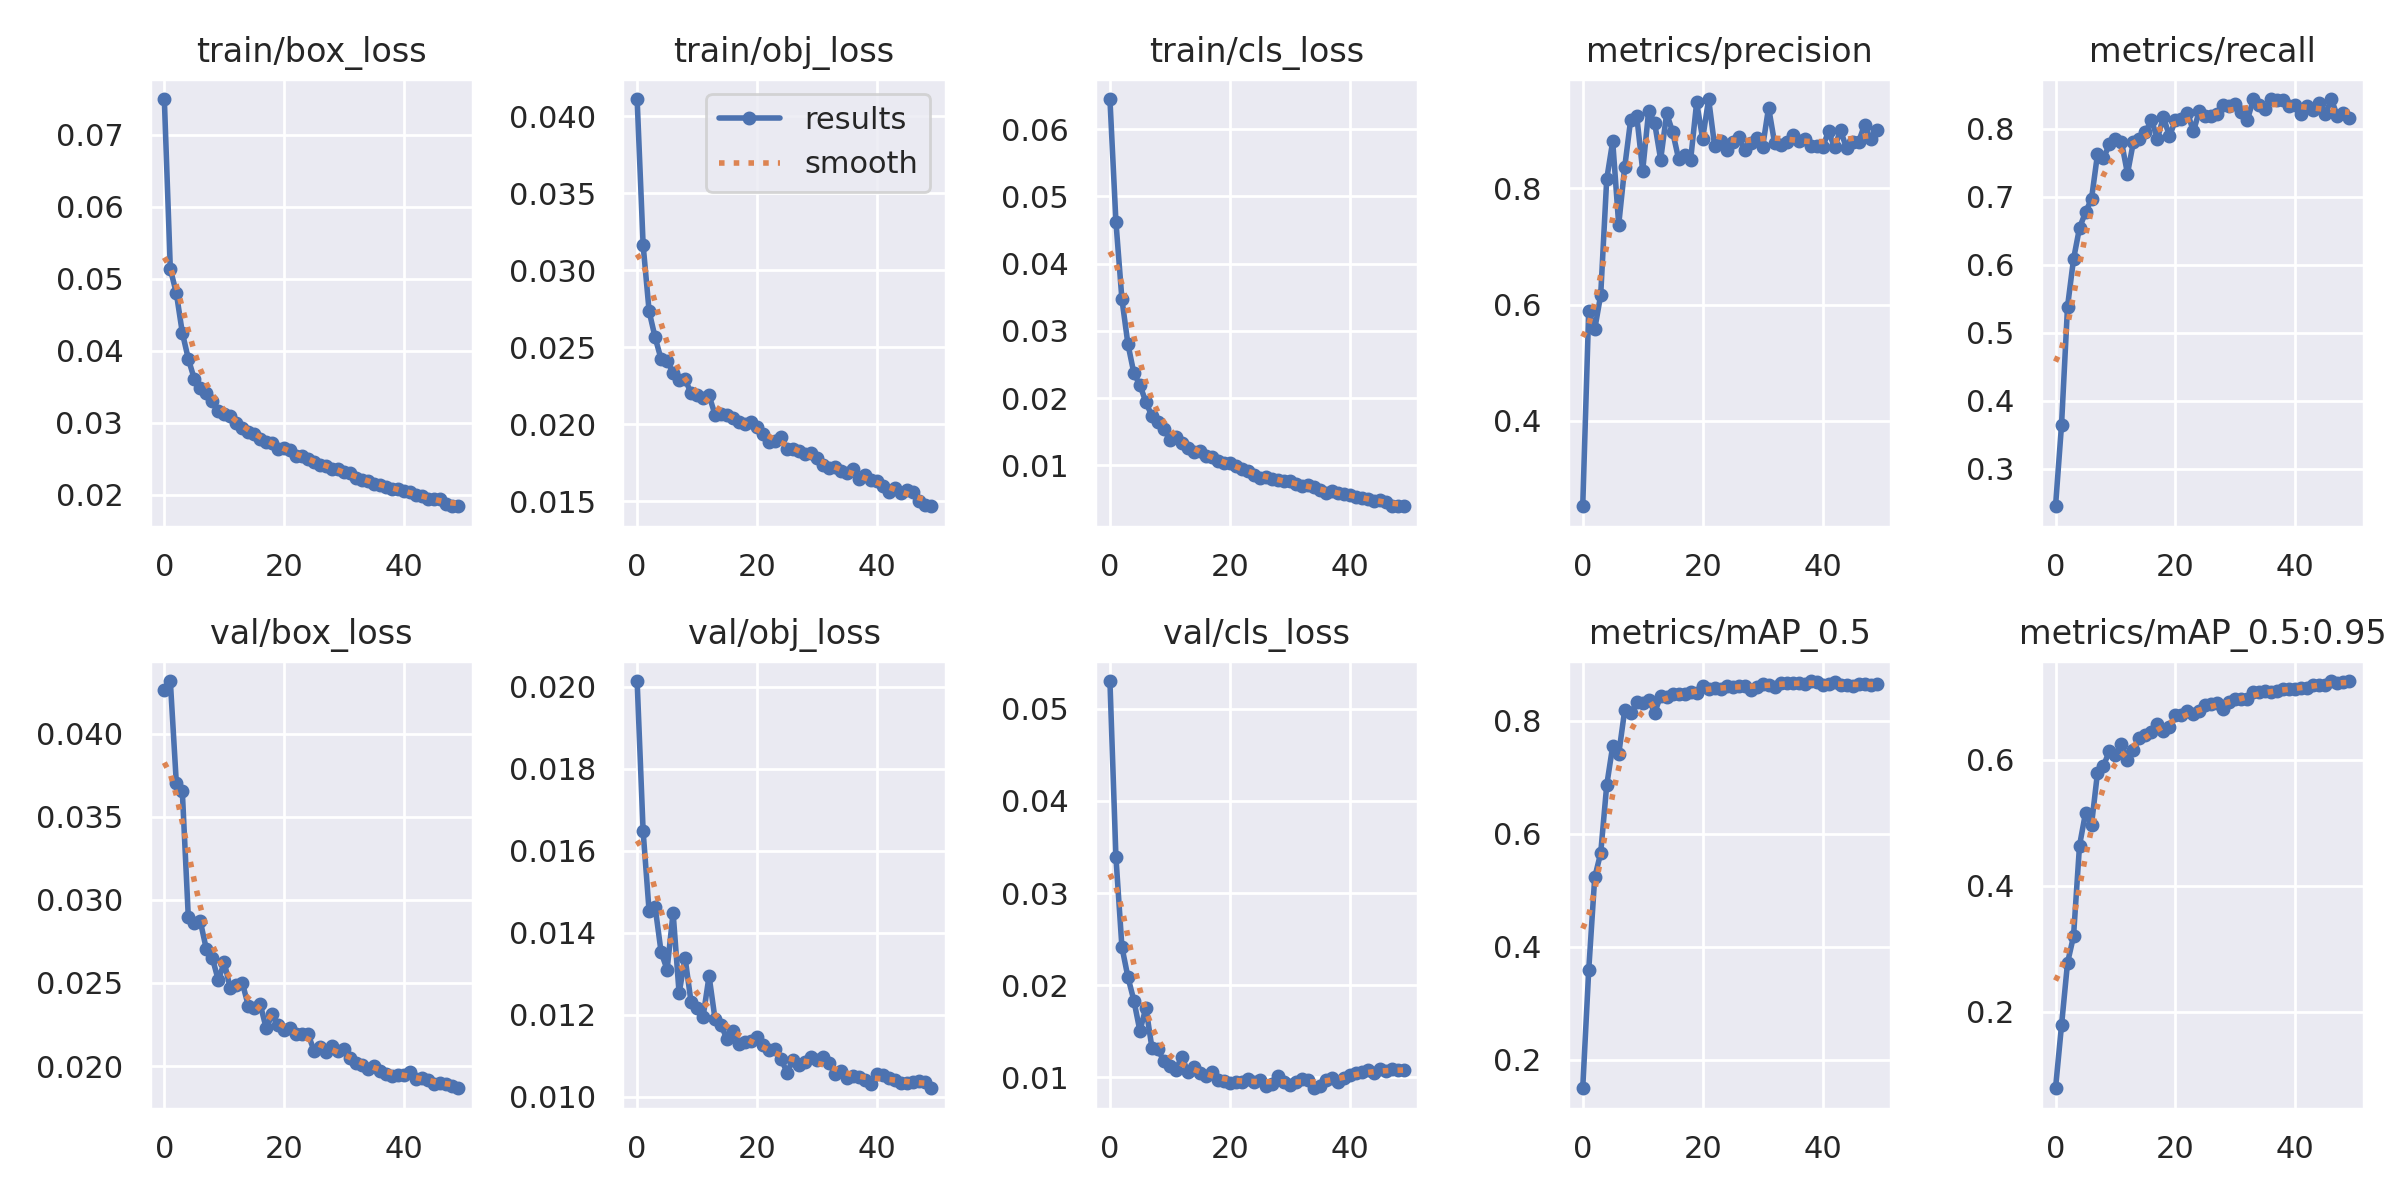

📊 P_curve.png


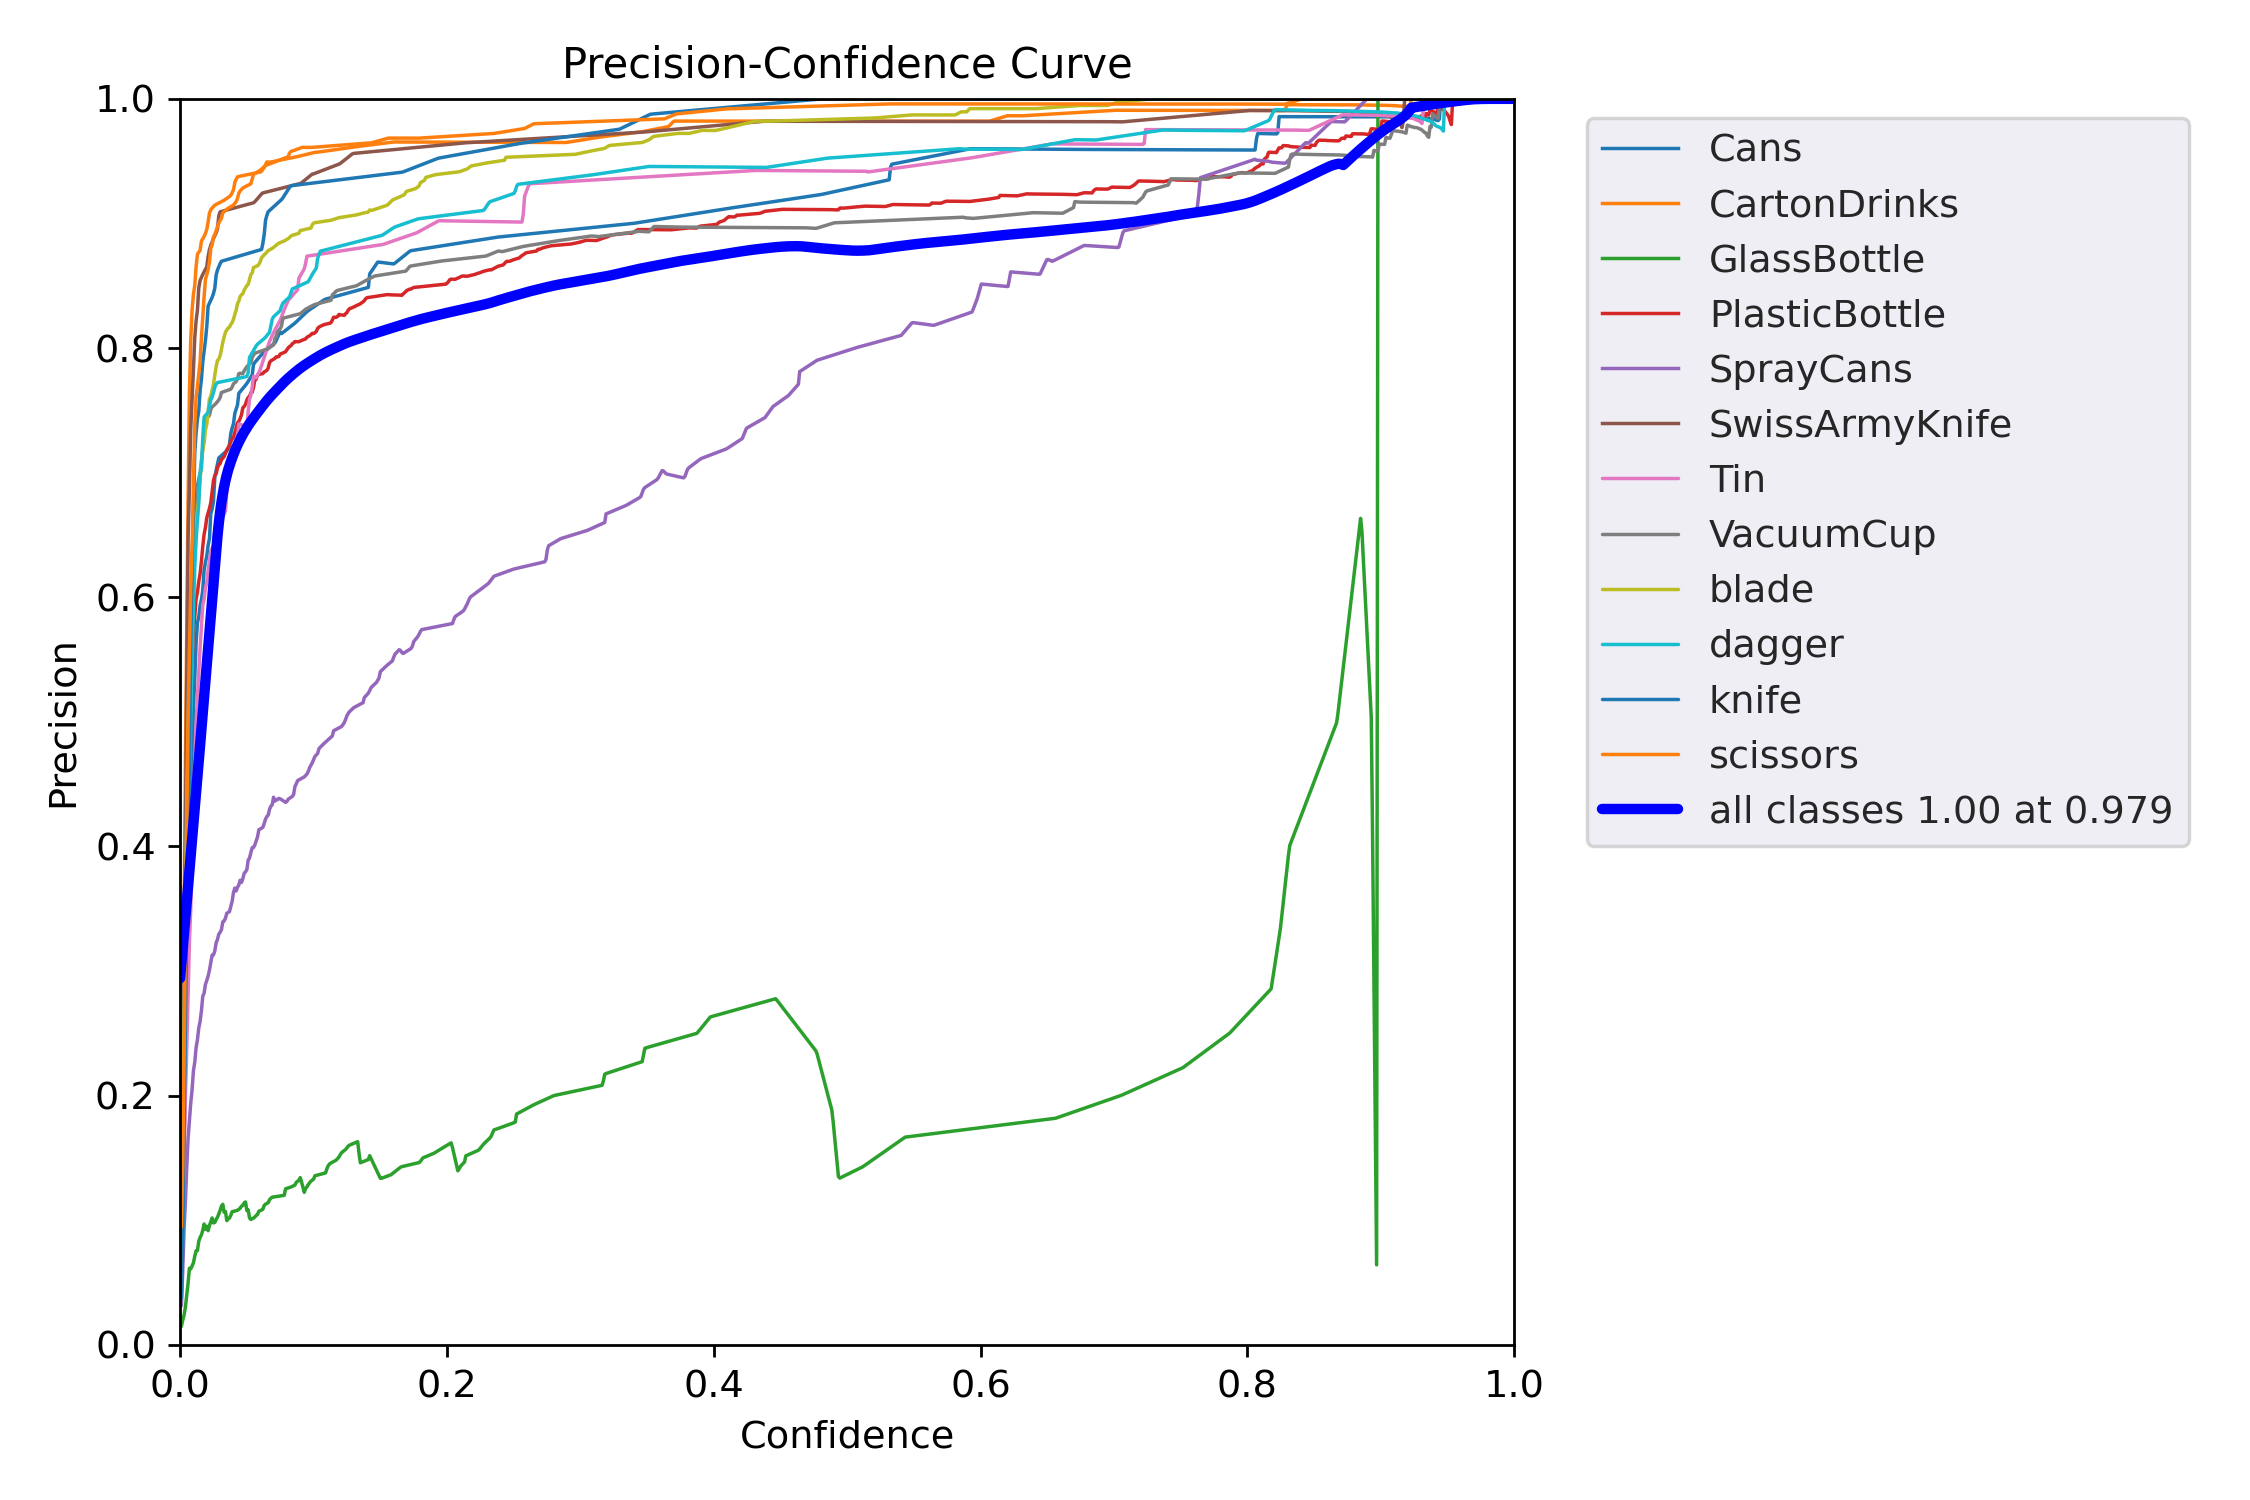

📊 R_curve.png


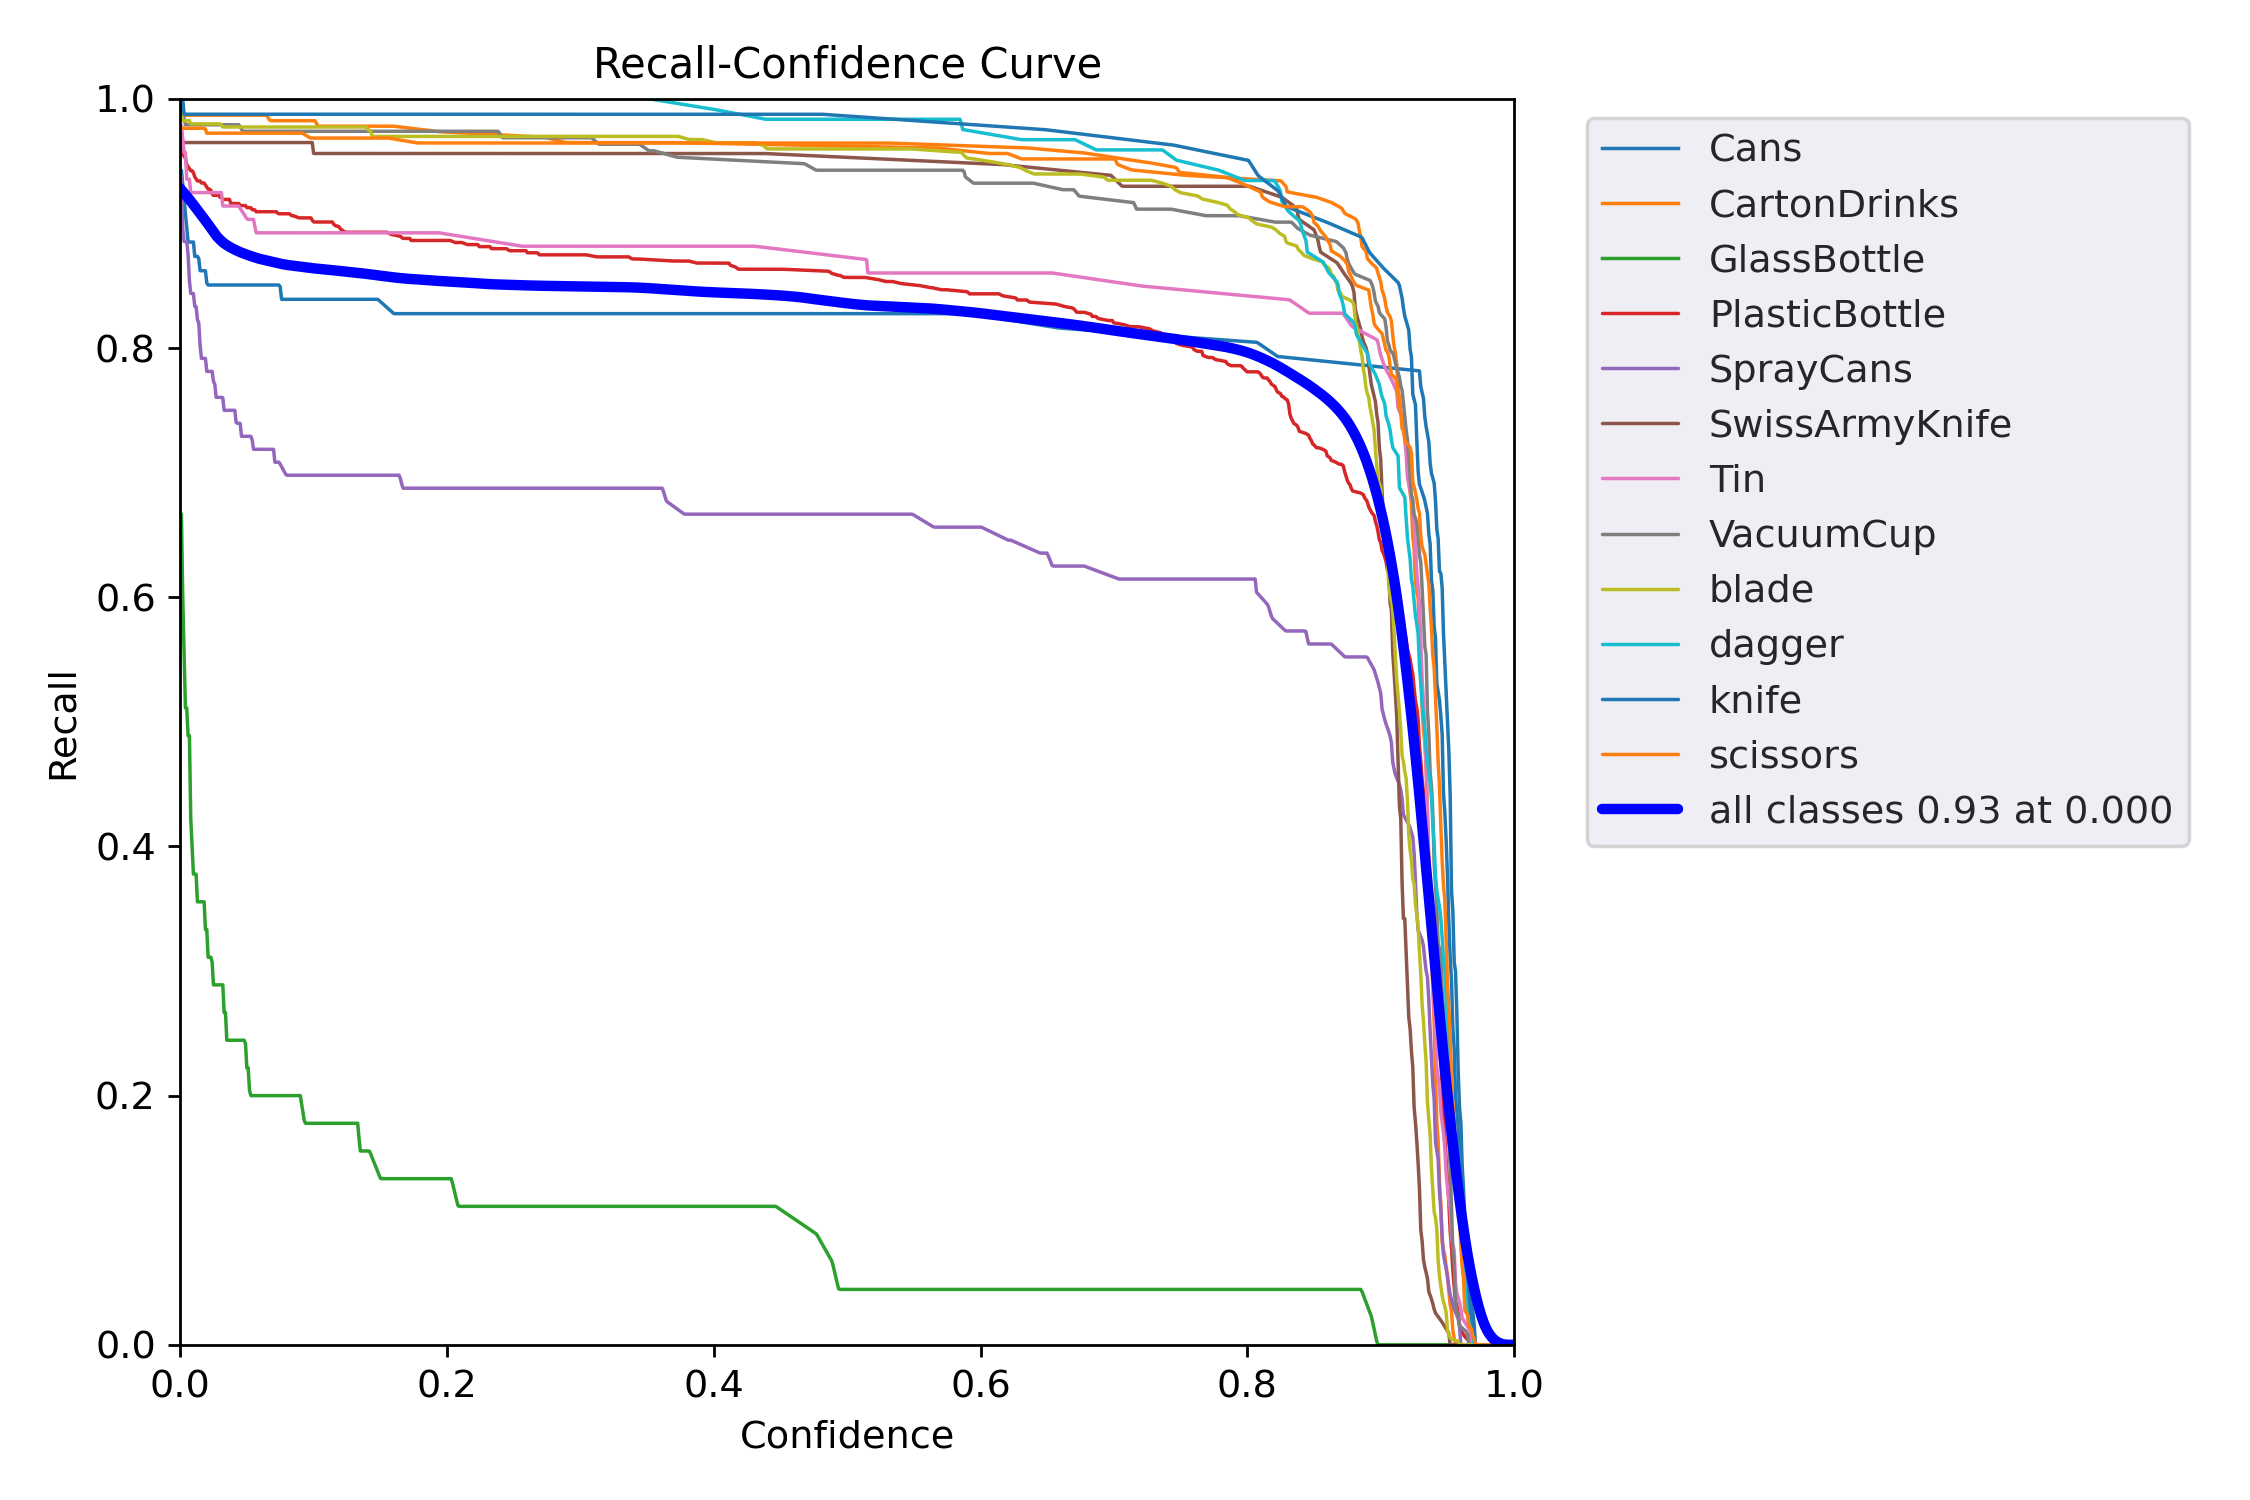

📊 PR_curve.png


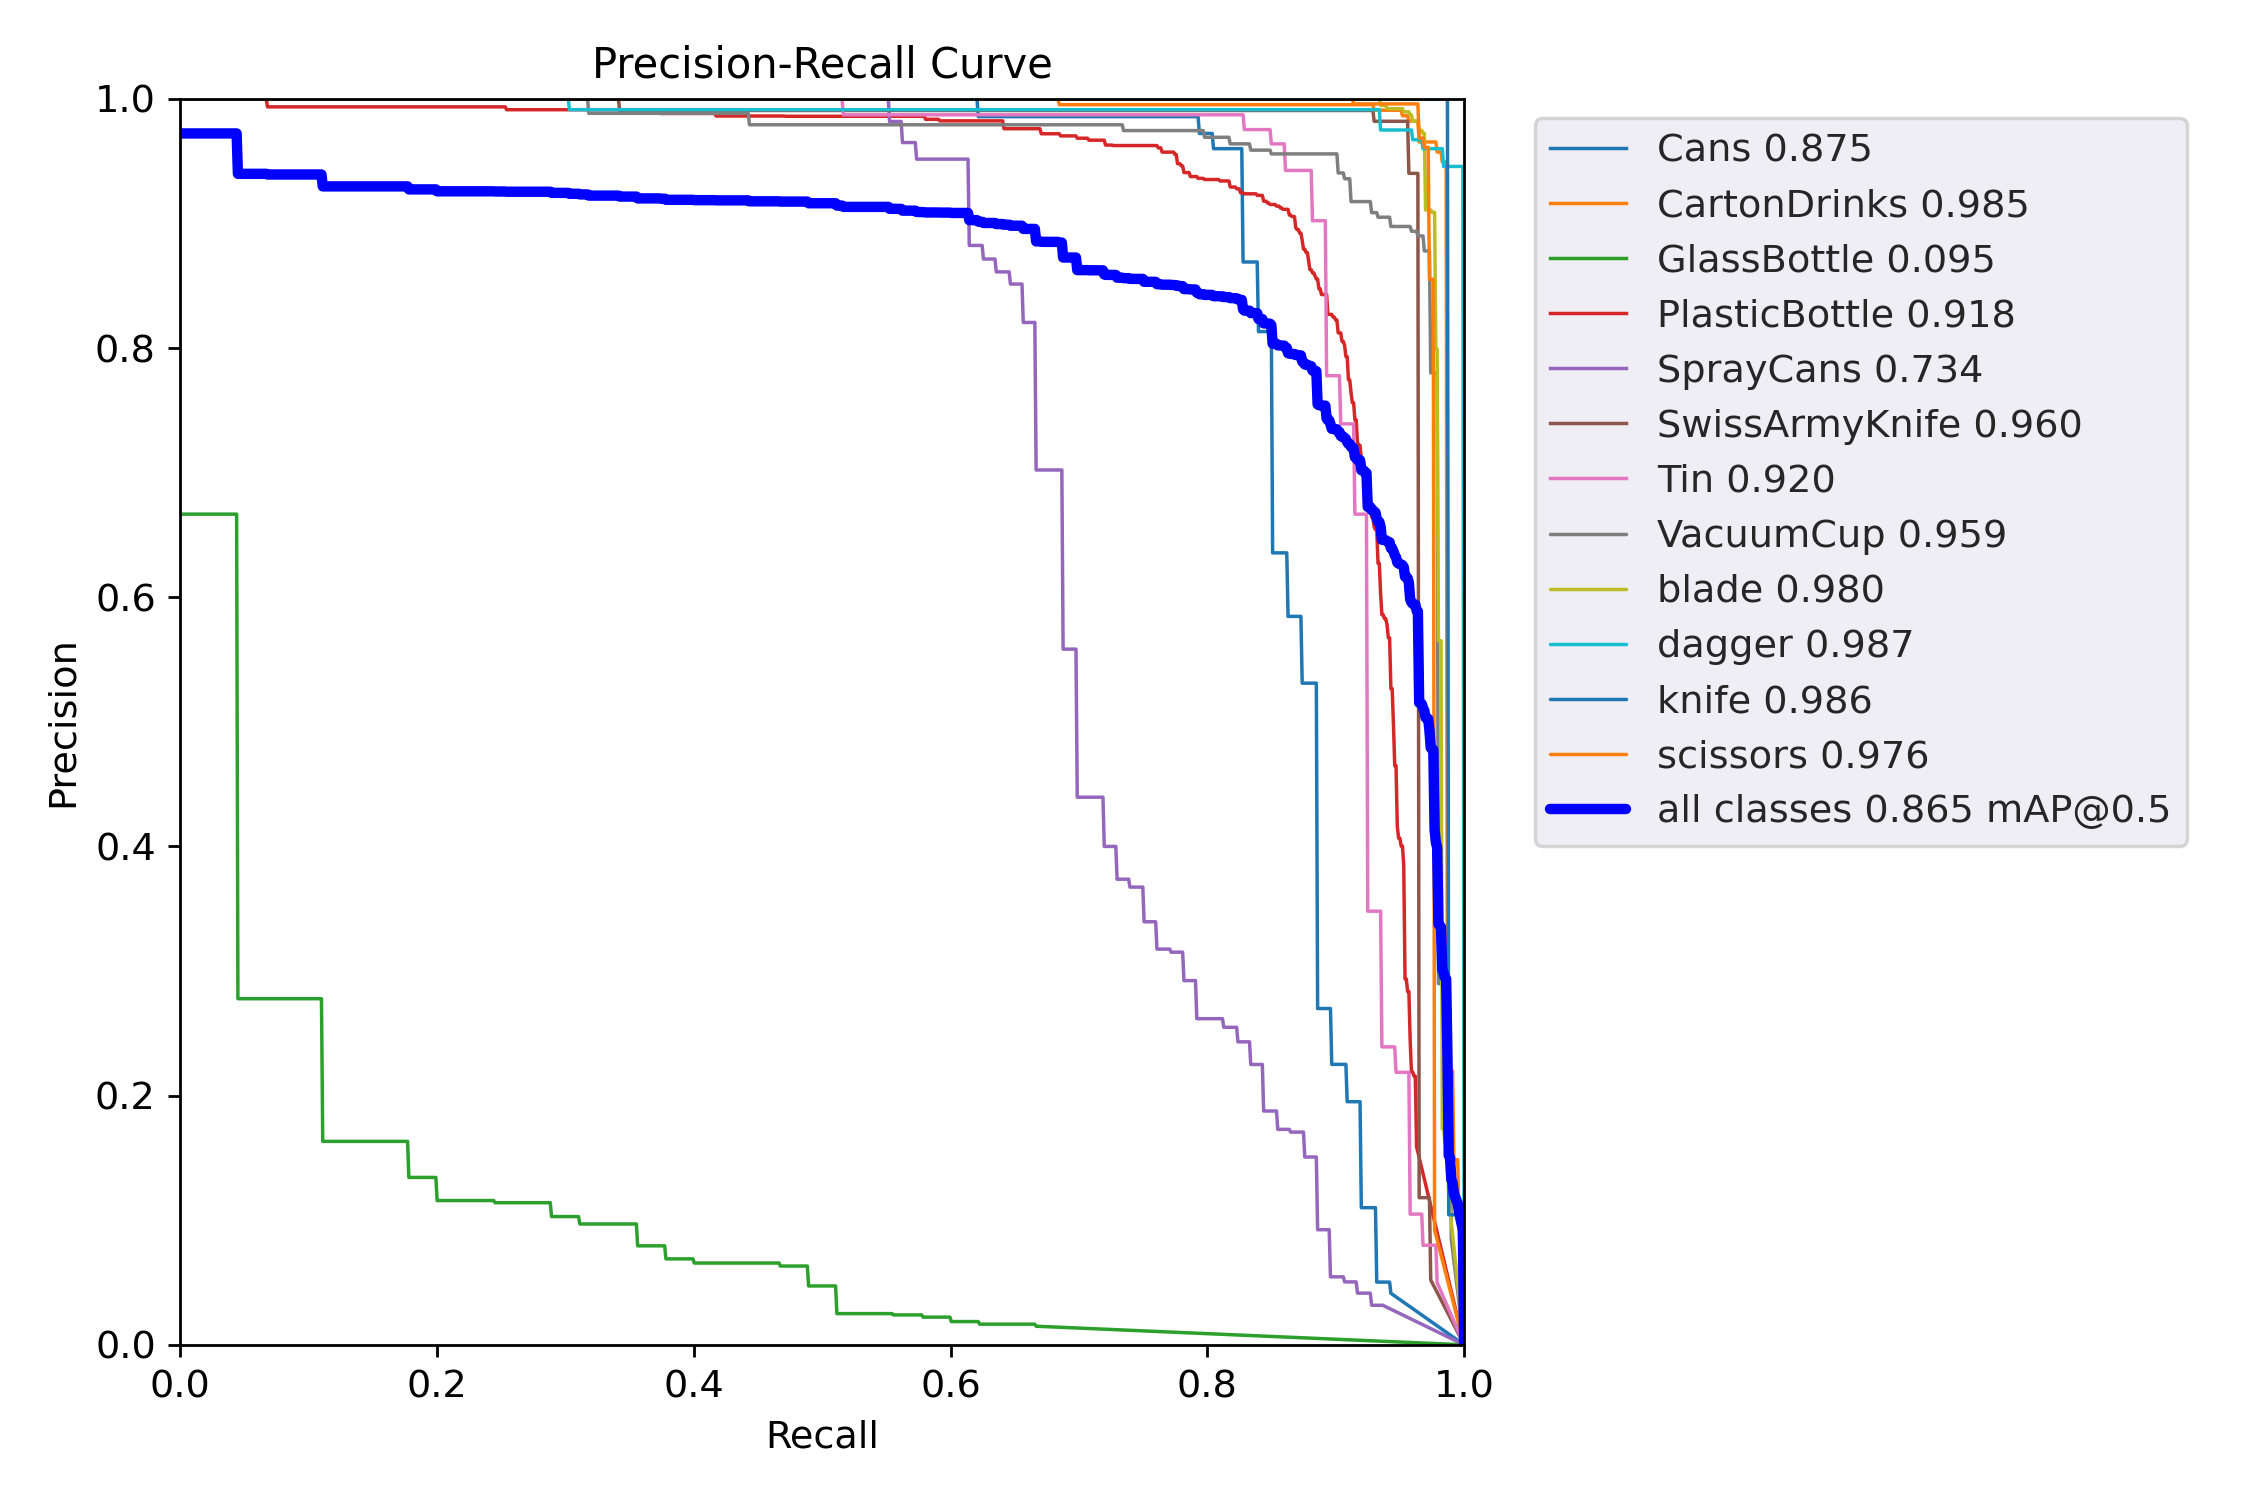

📊 F1_curve.png


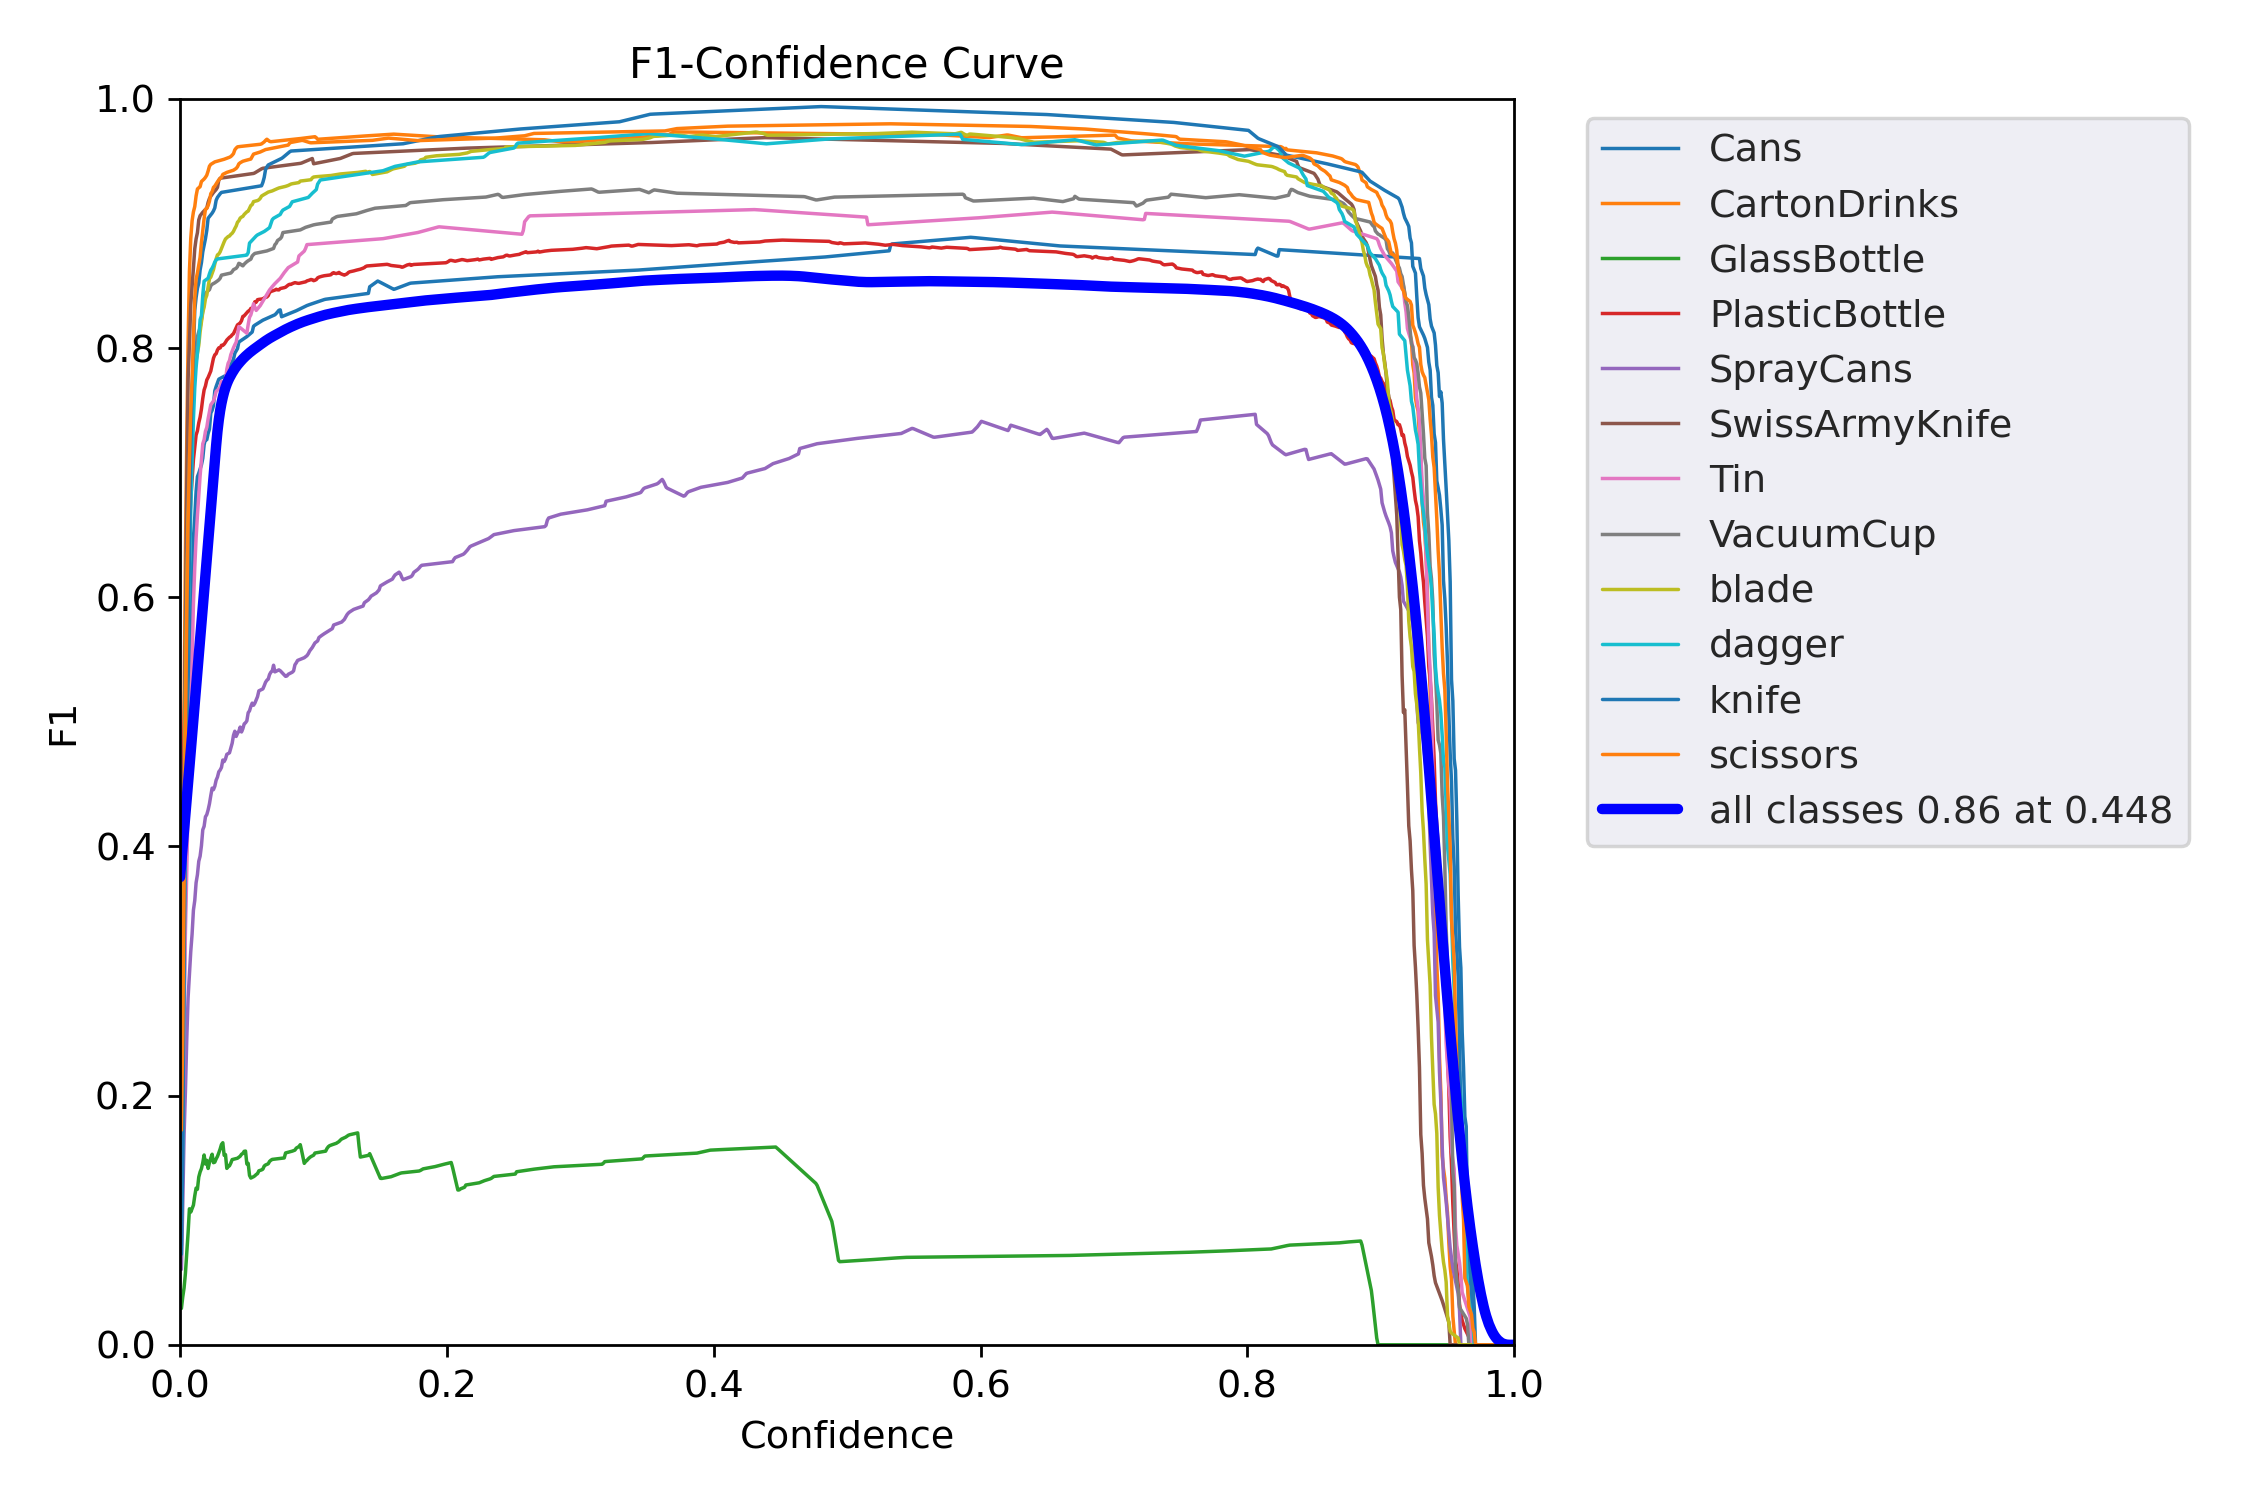

📊 confusion_matrix.png


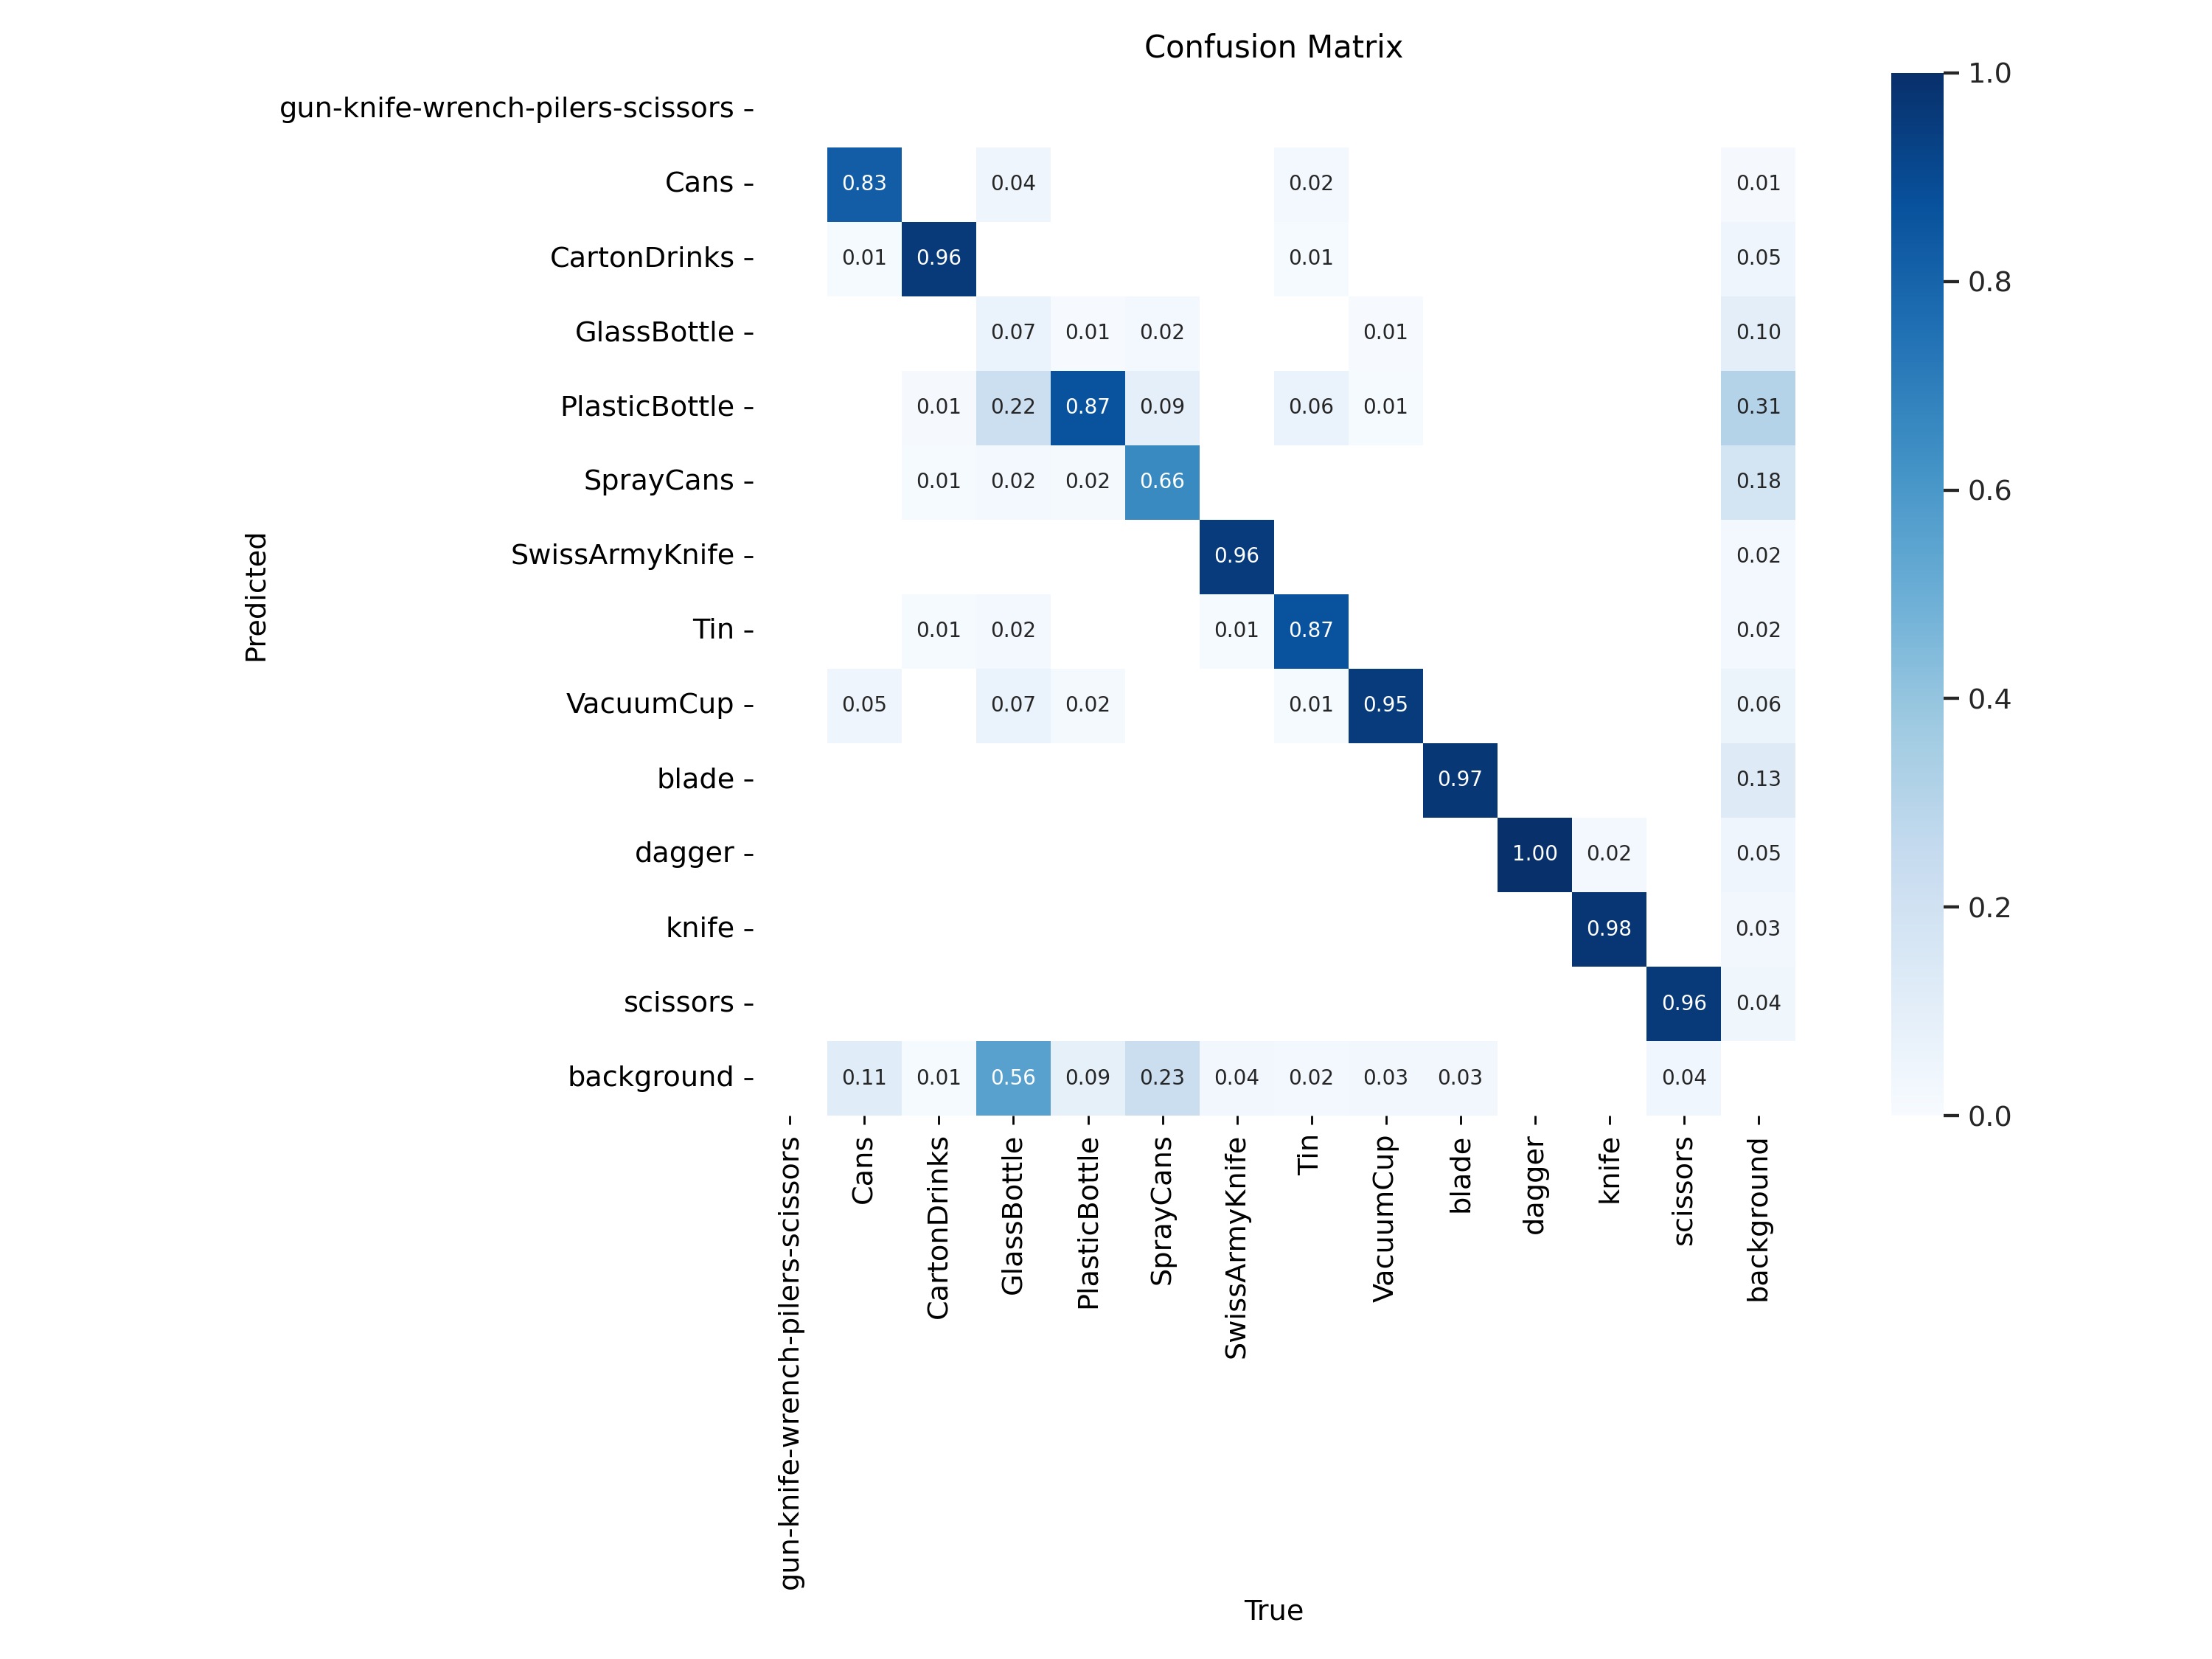

In [18]:
from IPython.display import Image, display

base_path = "/kaggle/working/yolo_results/clc-xray-yolov5s"

metric_imgs = [
    "results.png",
    "P_curve.png",
    "R_curve.png",
    "PR_curve.png",
    "F1_curve.png",
    "confusion_matrix.png"
]

for img in metric_imgs:
    print(f"📊 {img}")
    display(Image(filename=f"{base_path}/{img}"))
